<a href="https://colab.research.google.com/github/usembergstarling-cmyk/google-colabt/blob/main/Analisis_predictivo_de_precios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Predictivo de Precios de Vivienda
Este cuaderno compara dos modelos de aprendizaje automático para predecir el costo de las casas basándose en sus características.

In [7]:
import pandas as pd # Importo pandas para manejar las tablas de datos (DataFrames)
import numpy as np # Importo numpy para realizar operaciones matemáticas si es necesario
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# Como el archivo ya está en el sistema, lo cargamos directamente
archivo = '/content/Housing.csv'

try:
    df = pd.read_csv(archivo) # Leo el archivo local Housing.csv
    print("¡Archivo cargado correctamente desde el entorno de Colab!")
    display(df.head()) # Muestro los primeros registros para confirmar el éxito
except Exception as e:
    print(f"Error al leer el archivo local: {e}")

¡Archivo cargado correctamente desde el entorno de Colab!


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,9158483,5745,3,2,2,yes,yes,no,no,yes,3,yes,furnished
1,9445182,4792,5,1,3,yes,no,yes,no,yes,1,yes,semi-furnished
2,7692424,5971,4,2,2,no,no,no,yes,yes,2,no,semi-furnished
3,9654445,7284,5,1,1,yes,no,yes,no,yes,1,no,unfurnished
4,5824459,4648,2,2,1,no,no,no,no,no,1,no,furnished


In [8]:
# Para que los modelos funcionen, las palabras (Yes/No) deben ser números
# Aquí convierto las columnas categóricas en variables numéricas simples
df = pd.get_dummies(df, drop_first=True) # Transformo categorías en 0 y 1 para que el modelo las entienda

X = df.drop('price', axis=1) # X contiene todas las características de la casa (habitaciones, baños, etc.)
y = df['price'] # y es el objetivo que queremos predecir: el precio

# Divido los datos: 80% para enseñar al modelo y 20% para evaluar si aprendió bien
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Datos preparados correctamente")
display(df.head())

Datos preparados correctamente


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,9158483,5745,3,2,2,3,True,True,False,False,True,True,False,False
1,9445182,4792,5,1,3,1,True,False,True,False,True,True,True,False
2,7692424,5971,4,2,2,2,False,False,False,True,True,False,True,False
3,9654445,7284,5,1,1,1,True,False,True,False,True,False,False,True
4,5824459,4648,2,2,1,1,False,False,False,False,False,False,False,False


In [9]:
# --- MODELO 1: REGRESIÓN LINEAL ---
modelo_lineal = LinearRegression() # Creo el objeto del modelo de regresión lineal
modelo_lineal.fit(X_train, y_train) # Entreno el modelo usando los datos de entrenamiento
predicciones_lineales = modelo_lineal.predict(X_test) # Hago predicciones con los datos que el modelo no conoce
mae_lineal = mean_absolute_error(y_test, predicciones_lineales) # Calculo el error promedio de este modelo

# --- MODELO 2: ÁRBOL DE DECISIÓN ---
modelo_arbol = DecisionTreeRegressor(random_state=42) # Creo el objeto del árbol de decisión
modelo_arbol.fit(X_train, y_train) # Entreno el árbol con los mismos datos
predicciones_arbol = modelo_arbol.predict(X_test) # Hago predicciones usando la lógica de ramas del árbol
mae_arbol = mean_absolute_error(y_test, predicciones_arbol) # Calculo el error promedio del árbol

print(f"Error de Regresión Lineal (MAE): {mae_lineal:,.2f}") # Muestro el error del primer modelo
print(f"Error de Árbol de Decisión (MAE): {mae_arbol:,.2f}") # Muestro el error del segundo modelo

# Comparación personal del rendimiento
if mae_lineal < mae_arbol:
    print("\nAnálisis: La Regresión Lineal tuvo un mejor rendimiento al tener un error menor.")
else:
    print("\nAnálisis: El Árbol de Decisión tuvo un mejor rendimiento al tener un error menor.")

Error de Regresión Lineal (MAE): 656,919.65
Error de Árbol de Decisión (MAE): 1,095,826.49

Análisis: La Regresión Lineal tuvo un mejor rendimiento al tener un error menor.


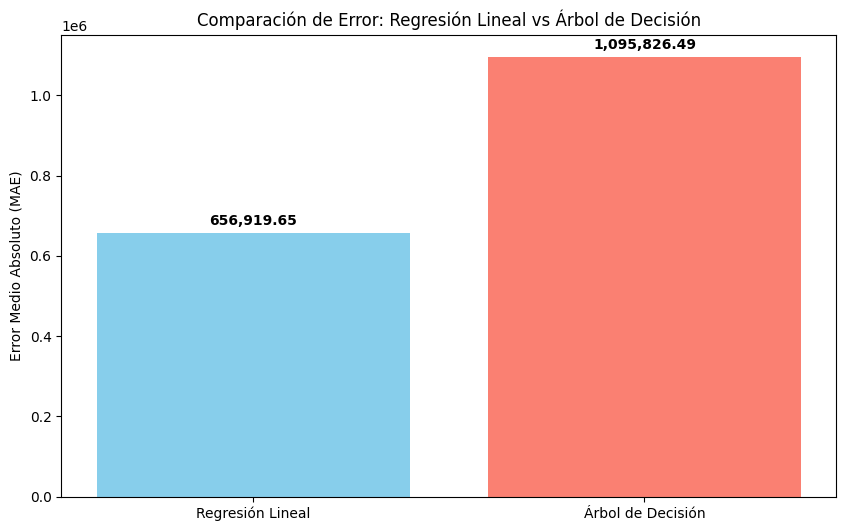

In [10]:
import matplotlib.pyplot as plt # Importo la librería para crear gráficos

# Preparo los datos para la gráfica
modelos = ['Regresión Lineal', 'Árbol de Decisión'] # Nombres de los modelos para el eje X
errores = [mae_lineal, mae_arbol] # Valores de los errores MAE para el eje Y

# Configuro el tamaño de la figura
plt.figure(figsize=(10, 6)) # Defino un tamaño adecuado para que se vea bien

# Creo la gráfica de barras
colores = ['skyblue', 'salmon'] # Elijo colores distintos para diferenciar los modelos
plt.bar(modelos, errores, color=colores) # Dibujo las barras con los datos y colores

# Añado etiquetas y título para que se entienda la información
plt.ylabel('Error Medio Absoluto (MAE)') # Etiqueta del eje vertical
plt.title('Comparación de Error: Regresión Lineal vs Árbol de Decisión') # Título del gráfico

# Añado el valor exacto encima de cada barra para mayor precisión
for i, v in enumerate(errores):
    plt.text(i, v + 20000, f'{v:,.2f}', ha='center', fontweight='bold') # Escribo el número sobre la barra

plt.show() # Muestro la gráfica final en el cuaderno

```markdown
# Conclusión Final del Proyecto
Tras comparar ambos modelos, los resultados indican que para este conjunto de datos de vivienda:

*   **El Modelo de Regresión Lineal** es el más adecuado, ya que presenta un error significativamente menor (~656,919).
*   **El Modelo de Árbol de Decisión** tiende a sobreajustarse o ser menos preciso con este volumen de datos (~1,095,826 de error).

Este cuaderno está documentado paso a paso para facilitar su comprensión y replicación en entornos de producción o investigación académica.
```